In [4]:
import pandas as pd
import matplotlib

 

In [28]:
costs = pd.read_csv('costs.csv')
costs.head()

,date,source,campaign,cost
0,2020-01-01,yandex_direct,gnrl|445275,130.08
1,2020-01-01,yandex_direct,gnrl|953233,117.67
2,2020-01-02,fb,gnrl|755263,64.42
3,2020-01-02,fb,lal|772023,197.11
4,2020-01-02,vk,lal|727027,153.02


In [24]:
orders = pd.read_csv('orders.csv')
orders.head()

,order_id,user_idi,order_amount,order_created_dt
0,768,2457,6440,2020-02-14
1,769,1486,6440,2020-02-16
2,770,2473,6440,2020-02-19
3,771,2132,6440,2020-02-21
4,772,2132,19900,2020-02-27


In [ ]:
# Взято с урока Алексея для примера 
# var_types = ['logistics', 'manufacturing', 'storing'] # Чаще всего именно переменные расходы растут с ростом продаж, именно они напрямую связаны с увеличением количества продаж

# cost.melt(id_vars='cost_type', var_name='months', value_name='costs') # Функция melt - Преобразует данные в более длинный формат
# .query('cost_type.isin(@var_types)') # Здесь отдаст дф с нужными значениями в колонке cost_type, которые мы передали списком
costs.date = pd.to_datetime(costs.date)
# costs.date.dt.to_period('M') # Большой модуль dt по работе с датами 
costs['cost_month'] = costs.date.dt.to_period('M')

<Axes: xlabel='cost_month'>

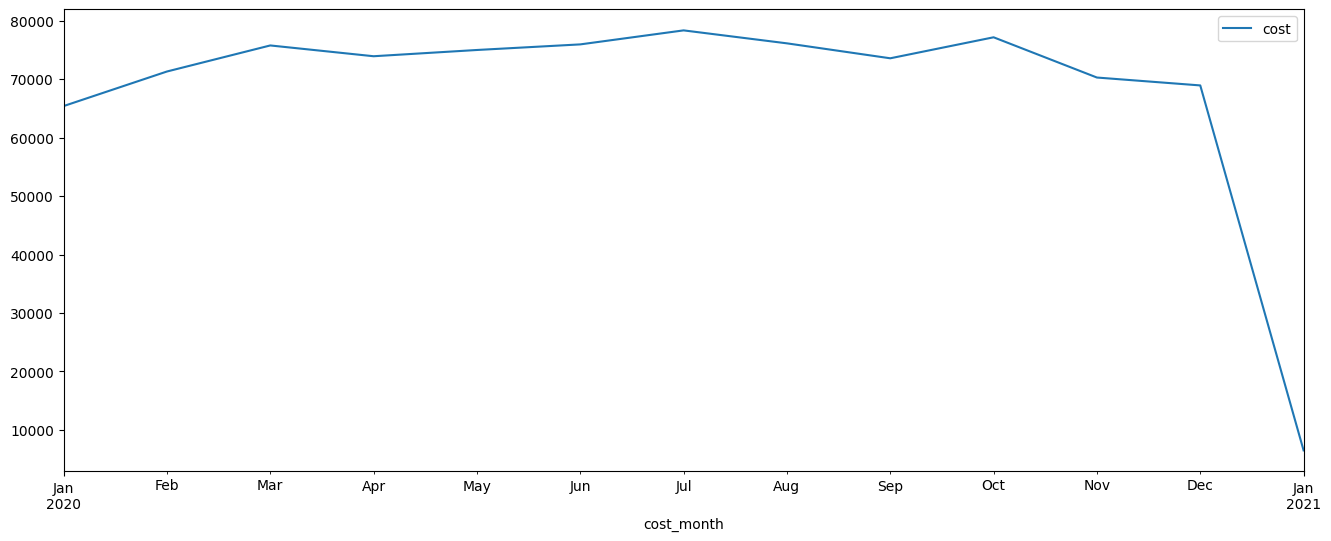

In [46]:
monthly_cost = (
    costs
    .groupby('cost_month')
    .agg({'cost': 'sum'})
    
)
monthly_cost.plot(figsize=(16,6))

In [63]:
orders.order_created_dt = pd.to_datetime(orders.order_created_dt)
orders['order_month'] = orders.order_created_dt.dt.to_period('M')
monthly_revenue = ( 
    orders
    .groupby('order_month')
    .agg(revenue = ('order_amount', 'sum'),
         orders = ('order_id', 'count'))
)
monthly_revenue['rev_per_order'] = (monthly_revenue['revenue'] / monthly_revenue['orders']).round(2)
# monthly_revenue.plot(figsize=(16,6))

<Axes: xlabel='order_month'>

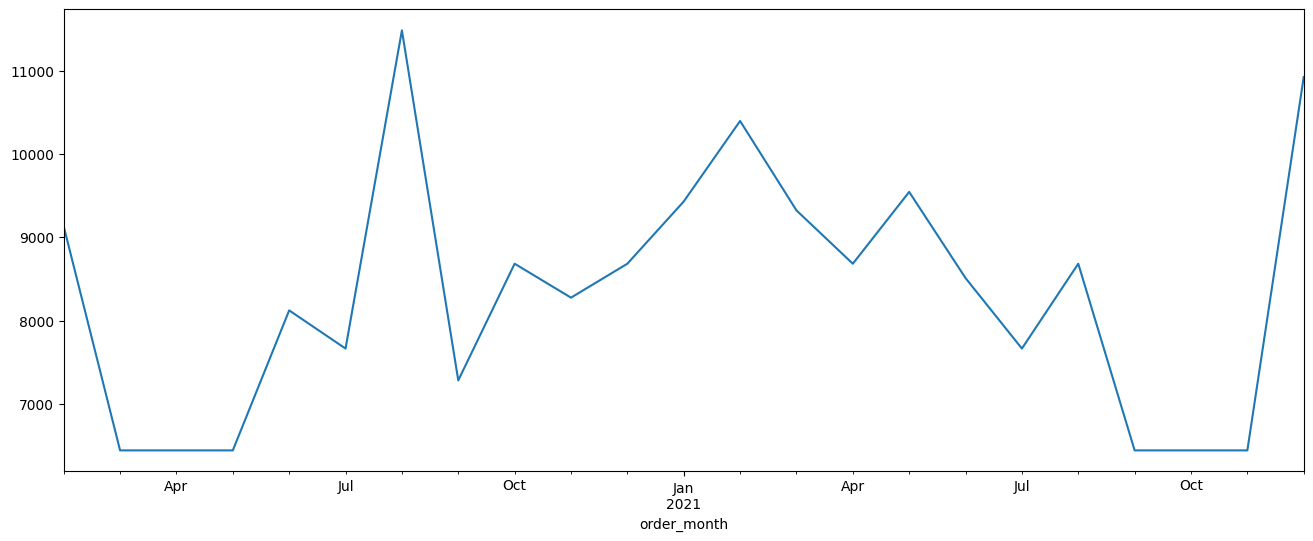

In [64]:
monthly_revenue['rev_per_order'].plot(figsize=(16,6))

<Axes: >

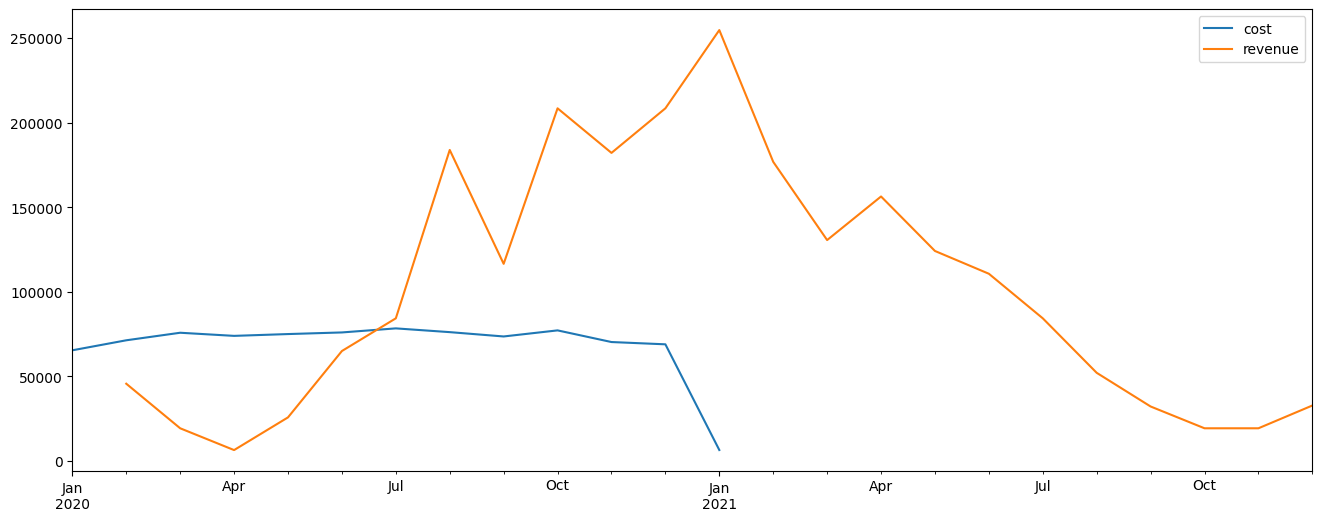

In [55]:
monthly_cost.join(monthly_revenue, how='outer').plot(figsize=(16,6)) # join как merge, только он склеивает индексы!


In [56]:
orders

,order_id,user_idi,order_amount,order_created_dt,order_month
0,768,2457,6440,2020-02-14,2020-02
1,769,1486,6440,2020-02-16,2020-02
2,770,2473,6440,2020-02-19,2020-02
3,771,2132,6440,2020-02-21,2020-02
4,772,2132,19900,2020-02-27,2020-02
...,...,...,...,...,...
262,1030,1469,6440,2021-11-23,2021-11
263,1031,2884,6440,2021-11-28,2021-11
264,1032,2418,6440,2021-12-18,2021-12
265,1033,2418,19900,2021-12-20,2021-12
